In [1]:
# Splice class labels
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
ORGANISM_NAMES = {0: "human", 1: "mouse"}

CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}


In [2]:
import pandas as pd

genome="/home/elek/sds/sd17d003/Anamaria/genomes/ensembl115/fasta/Homo_sapiens.fa"
coords = "1:14000-15000"

# Extract coordinates
if ":" in coords and "-" in coords:
    chrom, rest = coords.split(":", 1)
    start, end = rest.split("-")
elif ":" in coords:
    chrom, start, end = coords.split(":")
else:
    raise ValueError("Coordinates must be in 'chrom:start-end' or 'chrom:start:end' format")
start, end = int(start), int(end)

# We need chr lengtsh from fasta.fai
chr_lens = pd.read_csv(genome+".fai", sep='\t', header=None, usecols=[0, 1], names=['chrom', 'size'])
chr_len = int(chr_lens[chr_lens['chrom'] == chrom]['size'].values[0])

# Extract window centered on the region
seq_len = 131072
half = seq_len // 2
region_center = (start + end) // 2
win_start = max(region_center - half, 0)
if win_start == 0:
    win_end = min(seq_len, chr_len)
else:
    win_end = min(region_center + half, chr_len)
print(f"Predict for sequence {chrom}:{win_start}-{win_end}")

Predict for sequence 1:0-131072


In [4]:
# Load genome sequence
try:
    import pyfaidx
    fasta = pyfaidx.Fasta(genome, as_raw=True, sequence_always_upper=True)
except ImportError:
    raise ImportError("pyfaidx required: pip install pyfaidx")

seq_str = str(fasta[chrom][win_start:win_end])
seq_str

'...'

In [5]:
# One-hot encode sequence
import numpy as np
import torch
from alphagenome_pytorch.utils.sequence import sequence_to_onehot
device="cuda"
organism=0
seq_np = sequence_to_onehot(seq_str).astype(np.float32)  # (S, 4)
if seq_np.shape[0] != seq_len:
    # Pad with zeros if sequence is too short (e.g. near chromosome ends)
    pad_len = seq_len - seq_np.shape[0]
    seq_np = np.pad(seq_np, ((0, pad_len), (0, 0)), mode="constant")
seq_t = torch.from_numpy(seq_np).unsqueeze(0).to(device)  # (1, S, 4)
org_t = torch.full((1,), organism, dtype=torch.long, device=device)

In [6]:
from alphagenome_pytorch.utils.model_loading import load_model_for_inference

# pretrained model
checkpoint="/home/elek/projects/alphagenome_ft_pytorch/checkpoints/model_fold_0.safetensors"

model, cfg = load_model_for_inference(checkpoint, device, strict=False)

model.eval()

AlphaGenome(
  (encoder): SequenceEncoder(
    (dna_embedder): DnaEmbedder(
      (conv1): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
      (block): ConvBlock(
        (norm): RMSBatchNorm()
        (conv): StandardizedConv1d(768, 768, kernel_size=(5,), stride=(1,))
      )
    )
    (pool): Pool1d()
    (down_blocks): ModuleList(
      (0): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(768, 896, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 896, kernel_size=(5,), stride=(1,))
        )
      )
      (1): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 1024, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(1024, 1024, kernel_size=(5,), stride=(1,)

In [7]:
from alphagenome_pytorch.utils.model_loading import load_model_for_inference

# fine-tuned model
checkpoint="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_lora/best_model.pth"

model, cfg = load_model_for_inference(checkpoint, device, strict=False)

model.eval()

AlphaGenome(
  (encoder): SequenceEncoder(
    (dna_embedder): DnaEmbedder(
      (conv1): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
      (block): ConvBlock(
        (norm): RMSBatchNorm()
        (conv): StandardizedConv1d(768, 768, kernel_size=(5,), stride=(1,))
      )
    )
    (pool): Pool1d()
    (down_blocks): ModuleList(
      (0): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(768, 896, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 896, kernel_size=(5,), stride=(1,))
        )
      )
      (1): DownResBlock(
        (block1): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(896, 1024, kernel_size=(5,), stride=(1,))
        )
        (block2): ConvBlock(
          (norm): RMSBatchNorm()
          (conv): StandardizedConv1d(1024, 1024, kernel_size=(5,), stride=(1,)

## Splice site classification

In [7]:
# Predict splice site classification
with torch.no_grad():
    out = model.predict(seq_t, org_t, resolutions=(1,))
    probs = out["splice_sites_classification"]["probs"][0].cpu().numpy()  # (S, 5)

In [8]:
# Do probabilities sum to 1 per position?
per_pos_prob = probs.sum(axis=1)
print(f"Per-position probability sums: min={per_pos_prob.min():.4f}, max={per_pos_prob.max():.4f}")

Per-position probability sums: min=0.9980, max=1.0024


In [9]:
# Predicted classes across positions
pred_classes = np.argmax(probs, axis=-1)  # (S,)

# Count predicted classes
unique, counts = np.unique(pred_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        cls_probs = probs[:, cls]  # (S,)
        predicted_positions = np.where(pred_classes == cls)[0]  # Threshold at 0.2 for example
        print(f"  Predicted positions for class {cls}: {predicted_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = predicted_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls}: {genomic_positions}")

Class 2: 11 positions
  Predicted positions for class 2: [14969 15795 16606 16857 17232 17605 17914 18267 18912 24737 29320]
  Genomic coordinates for class 2: [14969 15795 16606 16857 17232 17605 17914 18267 18912 24737 29320]
Class 3: 13 positions
  Predicted positions for class 3: [14828 15037 15666 15890 16764 17054 17367 17741 18060 18365 18378 18553
 24890]
  Genomic coordinates for class 3: [14828 15037 15666 15890 16764 17054 17367 17741 18060 18365 18378 18553
 24890]
Class 4: 131048 positions


In [10]:
# Load splice site parquet annotation for the region
import pandas as pd
fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/splice_sites.parquet"
pq = pd.read_parquet(fn)

fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet"
usage_pq = pd.read_parquet(fn)

# Get true labels for the window we calculated predictions for
true_pq = pq[(pq['Chromosome'] == chrom) & (pq['Position'] >= win_start) & (pq['Position'] < win_end)]

# window coordinate
true_pq['WindowPosition'] = true_pq['Position'] - win_start

# Placeholder for background class
true_classes = np.full_like(pred_classes, fill_value=BACKGROUND_CLASS)

# Match SiteType to index in SPLICE_CLASS_NAMES
true_pq['TrueClass'] = true_pq['SiteType'].map({name: i for i, name in enumerate(SPLICE_CLASS_NAMES)})

# Fill placeholder with actual positive classes from parquet
true_classes[true_pq['WindowPosition'].values] = true_pq['TrueClass'].values

# Count true classes
unique, counts = np.unique(true_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} positions")
    if cls != 4:  # If not "no splice site" print which positions are predicted as this class
        true_positions = np.where(true_classes == cls)[0]
        print(f"  True positions for class {cls} (n={len(true_positions)}):\n{true_positions}")
        # Reconstruct genomic coordinates of predicted splice sites
        genomic_positions = true_positions + win_start  # Convert to genomic coordinates
        print(f"  Genomic coordinates for class {cls} (n={len(genomic_positions)}):\n{genomic_positions}")

Class 2: 13 positions
  True positions for class 2 (n=13):
[14969 15795 16857 16875 17232 17525 17605 17914 18345 18912 24737 24845
 92090]
  Genomic coordinates for class 2 (n=13):
[14969 15795 16857 16875 17232 17525 17605 17914 18345 18912 24737 24845
 92090]
Class 3: 15 positions
  True positions for class 3 (n=15):
[ 14536  14763  14828  15037  16764  17015  17054  17367  17741  18060
  18365  18368  24438  91628 129222]
  Genomic coordinates for class 3 (n=15):
[ 14536  14763  14828  15037  16764  17015  17054  17367  17741  18060
  18365  18368  24438  91628 129222]
Class 4: 131044 positions


In [11]:
# Calculate AUPR for each class (except background)
from sklearn.metrics import average_precision_score
for cls in range(4):
    true_labels = (true_classes == cls).astype(int)  # Binary labels for this class
    cls_probs = probs[:, cls]  # Predicted probabilities for this class
    aupr = average_precision_score(true_labels, cls_probs)
    print(f"AUPRC for class {cls} ({CLASS_LABELS[cls]}): {aupr:.4f}")

AUPRC for class 0 (donor +): 0.0000
AUPRC for class 1 (acceptor +): 0.0000
AUPRC for class 2 (donor -): 0.5980
AUPRC for class 3 (acceptor -): 0.4717


/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/sasselab3/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [12]:
# Combined dataframe with positions where true or predicted class is not background
pred_non_bg = pred_classes != BACKGROUND_CLASS
true_non_bg = true_classes != BACKGROUND_CLASS
non_bg_positions = np.where(pred_non_bg | true_non_bg)[0]
results_df = pd.DataFrame({
    "Window_position": non_bg_positions,
    "Genomic_position": non_bg_positions + win_start,
    "Predicted_class": pred_classes[non_bg_positions],
    "True_class": true_classes[non_bg_positions],
    "Donor+_prob": probs[non_bg_positions, 0],
    "Acceptor+_prob": probs[non_bg_positions, 1],
    "Donor-_prob": probs[non_bg_positions, 2],
    "Acceptor-_prob": probs[non_bg_positions, 3],
    "Background_prob": probs[non_bg_positions, 4],
})

results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob
0,14536,14536,4,3,4.563481e-07,3.024936e-06,0.000002,0.000082,1.000000
1,14763,14763,4,3,3.004074e-05,3.322959e-06,0.000013,0.000020,1.000000
2,14828,14828,3,3,6.780028e-07,2.431870e-05,0.000058,0.992188,0.007416
3,14969,14969,2,2,3.981590e-05,2.384186e-05,0.957031,0.001945,0.039551
4,15037,15037,3,3,6.742775e-07,4.649162e-05,0.000235,0.949219,0.050781
5,15666,15666,3,4,4.380941e-06,1.102686e-05,0.000194,0.605469,0.396484
6,15795,15795,2,2,5.513430e-06,3.308058e-06,0.964844,0.000296,0.035156
7,15890,15890,3,4,5.841255e-06,4.267693e-05,0.000683,0.625000,0.375000
8,16606,16606,2,4,9.775162e-06,5.155802e-06,0.957031,0.000298,0.043701
9,16764,16764,3,3,7.033348e-06,9.012222e-05,0.000660,0.640625,0.357422


In [13]:
# Add column indicating if prediction is correct
results_df['Correctly_Predicted'] = results_df['Predicted_class'] == results_df['True_class']

# Create a dictionary with max alpha for each position 
usage_w = usage_pq[(usage_pq['Chromosome'] == chrom) & (usage_pq['Position'] >= win_start) & (usage_pq['Position'] < win_end)]
alpha_max = {pos: usage_w.loc[usage_w['Position'] == pos, 'Alpha'].max() for pos in usage_w['Position'].unique()}

# Add max alpha to results dataframe
results_df['Alpha_max'] = results_df.apply(lambda row: alpha_max.get((row['Window_position'] + win_start), 0), axis=1)
results_df

,Window_position,Genomic_position,Predicted_class,True_class,Donor+_prob,Acceptor+_prob,Donor-_prob,Acceptor-_prob,Background_prob,Correctly_Predicted,Alpha_max
0,14536,14536,4,3,4.563481e-07,3.024936e-06,0.000002,0.000082,1.000000,False,51
1,14763,14763,4,3,3.004074e-05,3.322959e-06,0.000013,0.000020,1.000000,False,62
2,14828,14828,3,3,6.780028e-07,2.431870e-05,0.000058,0.992188,0.007416,True,614
3,14969,14969,2,2,3.981590e-05,2.384186e-05,0.957031,0.001945,0.039551,True,611
4,15037,15037,3,3,6.742775e-07,4.649162e-05,0.000235,0.949219,0.050781,True,383
5,15666,15666,3,4,4.380941e-06,1.102686e-05,0.000194,0.605469,0.396484,False,0
6,15795,15795,2,2,5.513430e-06,3.308058e-06,0.964844,0.000296,0.035156,True,383
7,15890,15890,3,4,5.841255e-06,4.267693e-05,0.000683,0.625000,0.375000,False,0
8,16606,16606,2,4,9.775162e-06,5.155802e-06,0.957031,0.000298,0.043701,False,21
9,16764,16764,3,3,7.033348e-06,9.012222e-05,0.000660,0.640625,0.357422,True,136


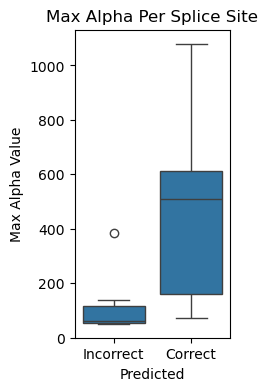

In [14]:
# Boxplot of max alpha values for correctly and incorrectly predicted splice sites
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(2, 4))
sns.boxplot(x='Correctly_Predicted', y='Alpha_max', data=results_df[results_df['True_class'] != BACKGROUND_CLASS])
plt.title("Max Alpha Per Splice Site")
plt.xlabel("Predicted")
plt.ylabel("Max Alpha Value")
#plt.yscale('log')
plt.xticks([0, 1], ['Incorrect', 'Correct'])
plt.show()

In [15]:
# How many true non-background positions?
n_trues = results_df["True_class"] != BACKGROUND_CLASS
n_false = results_df["True_class"] == BACKGROUND_CLASS
print(f"True positions: {n_trues.sum()}")
print(f"Background positions: {n_false.sum()}")

# How many are true positives (predicted non-background and true non-background)?
correct_non_bg = (results_df["Predicted_class"] == results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nTrue positives: {correct_non_bg.sum()}")
for cls in range(4):
    cls_correct = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_correct.sum()} positions")

# How many are false negatives (predicted background but true non-background)?
false_negatives = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] != BACKGROUND_CLASS)
print(f"\nFalse negatives: {false_negatives.sum()}")
for cls in range(4):
    cls_fn = (results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fn.sum()} positions")

# How many are misclassified (predicted non-background but true non-background, but predicted class is different from true class)?
misclassified = (results_df["Predicted_class"] != results_df["True_class"]) & (results_df["True_class"] != BACKGROUND_CLASS) & (results_df["Predicted_class"] != BACKGROUND_CLASS)
print(f"\nMisclassified: {misclassified.sum()}")
for cls in range(4):
    cls_mis = (results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_mis.sum()} positions")

# How many are false positives (predicted non-background but true background)?
false_positives = (results_df["Predicted_class"] != BACKGROUND_CLASS) & (results_df["True_class"] == BACKGROUND_CLASS)
print(f"\nFalse positives: {false_positives.sum()}")
for cls in range(4):
    cls_fp = (results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {cls_fp.sum()} positions")


True positions: 28
Background positions: 8

True positives: 16
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 8 positions
  Class 3 (acceptor -): 8 positions

False negatives: 12
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 5 positions
  Class 3 (acceptor -): 7 positions

Misclassified: 0
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 0 positions
  Class 3 (acceptor -): 0 positions

False positives: 8
  Class 0 (donor +): 0 positions
  Class 1 (acceptor +): 0 positions
  Class 2 (donor -): 3 positions
  Class 3 (acceptor -): 5 positions


In [16]:
summary_df = pd.DataFrame({
    "Class": [CLASS_LABELS[cls] for cls in range(4)],
    "True positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False negatives": [((results_df["Predicted_class"] == BACKGROUND_CLASS) & (results_df["True_class"] == cls)).sum() for cls in range(4)],
    "Misclassified": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] != cls) & (results_df["True_class"] != BACKGROUND_CLASS)).sum() for cls in range(4)],
    "False positives": [((results_df["Predicted_class"] == cls) & (results_df["True_class"] == BACKGROUND_CLASS)).sum() for cls in range(4)],
})
summary_df

,Class,True positives,False negatives,Misclassified,False positives
0,donor +,0,0,0,0
1,acceptor +,0,0,0,0
2,donor -,8,5,0,3
3,acceptor -,8,7,0,5


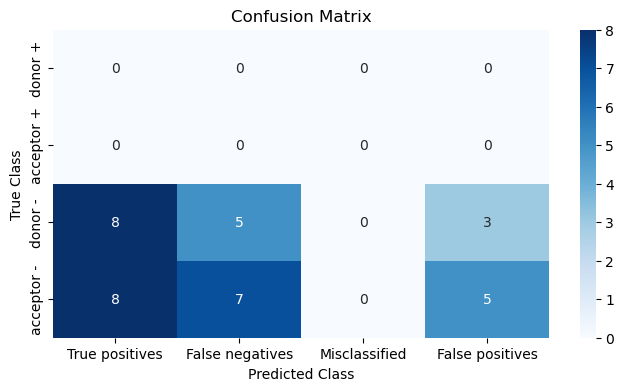

In [17]:
# Plot as heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(summary_df.set_index("Class"), annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## Splice usage

In [43]:
# Predict splice site usage (robust for pretrained and fine-tuned checkpoints)
with torch.no_grad():
    preds = model.predict(seq_t, org_t, resolutions=(1,))

    if "splice_sites_usage" in preds:
        # Standard path: head is attached directly to model
        usage = preds["splice_sites_usage"]["predictions"][0].cpu().numpy()
    elif hasattr(model, "usage_heads") and str(organism) in model.usage_heads:
        # Fine-tuned path: per-organism usage head stored separately
        emb = model.predict(
            seq_t,
            org_t,
            resolutions=(1,),
            channels_last=False,
            embeddings_only=True,
        )["embeddings_1bp"]  # (B, C, S)

        usage = model.usage_heads[str(organism)](
            emb, org_t, channels_last=True
        )["predictions"][0].float().cpu().numpy()
    else:
        raise RuntimeError(
            "No splice usage head found for this checkpoint/organism."
        )

print("usage shape:", usage.shape)  # (S, n_conditions)
usage

usage shape: (131072, 86)


array([[0.41112208, 0.34167096, 0.21117412, ..., 0.43448135, 0.11053316,
        0.68995404],
       [0.40935913, 0.34138596, 0.20605302, ..., 0.4365515 , 0.10716519,
        0.6842305 ],
       [0.41426432, 0.33145127, 0.20644397, ..., 0.432423  , 0.11097207,
        0.704712  ],
       ...,
       [0.45420837, 0.21920127, 0.21568705, ..., 0.3501446 , 0.21308817,
        0.3863115 ],
       [0.3679583 , 0.22937556, 0.19019398, ..., 0.35598963, 0.2088773 ,
        0.37657198],
       [0.33141714, 0.21023655, 0.22262536, ..., 0.28485295, 0.21590164,
        0.33776495]], shape=(131072, 86), dtype=float32)

In [ ]:
# Compare to true usage values from parquet
fn="/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.parquet"
usage_pq = pd.read_parquet(fn)

# Get usage values for positions in window
w_usage = usage_pq[
    (usage_pq["Chromosome"] == chrom) & 
    (usage_pq["Position"] >= start) & 
    (usage_pq["Position"] <= end)]

# Select condition to compare
i = 0
i_usage = w_usage[w_usage['Condition'] == i]
i_usage

,Chromosome,Position,SSE,Alpha,Beta,Label,Condition
0,1,14763,0.176,9,42,3,0
1,1,14763,0.104,14,121,3,0
2,1,14828,0.912,31,3,3,0
3,1,14828,0.886,31,4,3,0
4,1,14828,0.903,112,12,3,0
...,...,...,...,...,...,...,...
65546680,1,14828,0.873,48,7,3,85
65546681,1,14969,0.809,38,9,2,85
65546682,1,14969,0.943,50,3,2,85
65546683,1,14969,0.700,28,12,2,85


In [ ]:
true_pos = i_usage['Position'].drop_duplicates().values
pred_vals = usage[true_pos, i]
pred_vals

array([0.28101477, 0.46255782, 0.545971  ], dtype=float32)

: 

Evaluate correation between predicted and true values

In [ ]:
import numpy as np
import pandas as pd

# Column names
chrom_col = "Chromosome"
pos_col = "Position"
cond_col = "Condition"
true_col = "SSE"

# Keep rows for current region/chromosome
u = usage_pq.copy()
u[chrom_col] = u[chrom_col].astype(str)
u[pos_col] = u[pos_col].astype(int)
u[cond_col] = u[cond_col].astype(int)

# Optional remove background rows if present
if "Label" in u.columns:
    u = u[u["Label"] != 4]
    
# Try both coordinate conventions and keep the one with more valid matches
def _build_eval_df(df, pos_shift):
    rows = []
    for r in df.itertuples(index=False):
        chrom_r = str(getattr(r, chrom_col))
        if chrom_r != str(chrom):
            continue

        gpos = int(getattr(r, pos_col)) + pos_shift  # 0 if already 0-based, -1 if 1-based
        if gpos < win_start or gpos >= win_end:
            continue

        rel = gpos - win_start
        cond = int(getattr(r, cond_col))
        if rel < 0 or rel >= usage.shape[0]:
            continue
        if cond < 0 or cond >= usage.shape[1]:
            continue

        true_val = float(getattr(r, true_col))
        pred_val = float(usage[rel, cond])
        rows.append((gpos, rel, cond, true_val, pred_val))

    return pd.DataFrame(rows, columns=["gpos", "rel_pos", "condition", "true_usage", "pred_usage"])

eval_df_0 = _build_eval_df(u, pos_shift=0)
eval_df_m1 = _build_eval_df(u, pos_shift=-1)
eval_df = eval_df_m1 if len(eval_df_m1) > len(eval_df_0) else eval_df_0
coord_shift_used = -1 if len(eval_df_m1) > len(eval_df_0) else 0

if eval_df.empty:
    raise RuntimeError(
        "No overlapping usage labels could be aligned to predictions in this window. "
        "Check chromosome naming and coordinate convention."
    )

In [25]:
# Compare predicted vs true usage (overall)
overall_pearson = eval_df["true_usage"].corr(eval_df["pred_usage"], method="pearson")
overall_spearman = eval_df["true_usage"].corr(eval_df["pred_usage"], method="spearman")

print(f"Matched points: {len(eval_df):,}")
print(f"Coordinate shift used: {coord_shift_used} (0=already 0-based, -1=1-based to 0-based)")
print(f"Overall Pearson r:  {overall_pearson:.4f}")
print(f"Overall Spearman ρ: {overall_spearman:.4f}")

# Per-condition correlation (conditions with at least 2 matched points)
per_condition_corr = (
    eval_df.groupby("condition")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "pearson_r": g["true_usage"].corr(g["pred_usage"], method="pearson"),
            "spearman_rho": g["true_usage"].corr(g["pred_usage"], method="spearman"),
        })
    )
    .reset_index()
    .sort_values(["n", "pearson_r"], ascending=[False, False])
    .reset_index(drop=True)
)

per_condition_corr.head(20)

Matched points: 7,698
Coordinate shift used: 0 (0=already 0-based, -1=1-based to 0-based)
Overall Pearson r:  0.2830
Overall Spearman ρ: 0.2820


,condition,n,pearson_r,spearman_rho
0,17,278.0,0.441903,0.531686
1,33,236.0,0.510911,0.451119
2,16,232.0,0.480191,0.442585
3,59,232.0,0.010312,-0.031882
4,11,210.0,0.400380,0.432918
5,22,208.0,0.677817,0.643467
6,75,199.0,0.557093,0.576199
7,39,193.0,0.693310,0.673017
8,5,187.0,0.568474,0.461443
9,4,170.0,0.228819,0.538726
